In [1]:
# 표준 라이브러리
from pathlib import Path
import platform
from typing import List, Sequence, Any
import sys
import os

# 서드 파티 라이브러리
import pandas as pd
import numpy as np
from numpy.typing import ArrayLike

## 시각화 모듈
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Colormap
import seaborn as sns
import plotly.graph_objects as go

## 통계 모듈
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 머신러닝 모듈
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 로컬 모듈
sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / 'src'))
from src.plot import plot_box, plot_hist, plot_stacked_bar, plot_heatmap, plot_prop_bar, plot_mean_sem, plot_scatter_jitter
from src.utils import cramers_v, interpret_cramers_v, check_expected_frequencies, standardized_residuals
from src.utils import check_normality, check_homogeneity, calculate_eta_squared, calculate_epsilon_squared, perform_dunn_test, perform_gameshowell, perform_tukey_hsd

DATA_DIR = Path('../data/processed')

In [2]:
system = platform.system()

if system == 'Windows':
    # Windows: 맑은 고딕 사용
    plt.rcParams['font.family'] = 'Malgun Gothic'
    
elif system == 'Darwin':  # Darwin = macOS
    # macOS: 애플 고딕 사용
    plt.rcParams['font.family'] = 'AppleGothic'
    
elif system == 'Linux':
    # Linux: 나눔 고딕 사용 (사전 설치 필요)
    # 터미널: sudo apt-get install -y fonts-nanum
    plt.rcParams['font.family'] = 'NanumGothic'
    
else:
    print(f"알 수 없는 OS: {system}")

# 모든 OS 공통: 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print(f"OS: {system}, 설정된 폰트: {plt.rcParams['font.family']}")

OS: Linux, 설정된 폰트: ['NanumGothic']


In [3]:
pandas_kwargs = {
    'parse_dates': ['purchase_time', 'approved_time', 'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time'],
    'date_format': '%Y-%m-%d %H:%M:%S',
    'memory_map': True
}

processed_data: pd.DataFrame = pd.read_csv(DATA_DIR / 'processed_data.csv', **pandas_kwargs)
processed_data

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,customer_unique_id,order_id,product_id,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell
0,가구·인테리어,4.0,1,124.99,21.88,NaN,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,...,861eff4711a542e4b93843c6dd7febb0,00e7ee1b050b8499577073aeb2a297a1,a9516a079e37a9c9c36b9b78b10169e8,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
1,생활용품,5.0,1,289.00,46.48,NaN,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,...,290c77bc529b7ac935b93aa66c333dc3,29150127e6685892b6eab3eec79f59c7,4aa6014eceb682077f9dc4bffebc05b0,1,b8bc237ba3788b23da09c0f1f3a3288c,88303,itajai,SC,-26.920912,-48.684937
2,가구·인테리어,5.0,1,139.94,17.79,NaN,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,...,060e732b5b29e8181a18229c7b0b2b5e,b2059ed67ce144a36e2aa97d2c9e9ad2,bd07b66896d6f1494f5b86251848ced7,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
3,가구·인테리어,5.0,1,149.94,23.36,NaN,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,...,259dac757896d24d7702b9acbbff3f3c,951670f92359f4fe4a63112aa7306eba,a5647c44af977b148e0a3a4751a09e2e,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819
4,가구·인테리어,5.0,1,230.00,22.25,NaN,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,...,345ecd01c38d18a9036ed96c73b8d066,6b7d50bd145f6fc7f33cebabd7e49d0f,9391a573abe00141c56e38d84d7d5b3b,1,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101116,도서·미디어,4.0,1,74.90,13.88,NaN,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,...,1a29b476fee25c95fbafc67c5ac95cf8,6760e20addcf0121e9d58f2f1ff14298,ccb4503d9d43d245d3b295d0544f988b,1,527801b552d0077ffd170872eb49683b,17400,garca,SP,-22.210402,-49.662731
101117,스포츠·레저,5.0,1,114.90,14.16,NaN,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,...,d52a67c98be1cf6a5c84435bd38d095d,9ec0c8947d973db4f4e8dcf1fbfa8f1b,9ede6b0570a75a4b9de4f383329f99ee,1,3fd1e727ba94cfe122d165e176ce7967,14802,araraquara,SP,-21.775406,-48.168105
101118,건강·뷰티,1.0,1,37.00,19.04,NaN,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,...,e9f50caf99f032f0bf3c55141f019d99,fed4434add09a6f332ea398efd656a5c,7a5d2e1e131a860ae7d18f6fffa9d689,1,d9e7e7778b32987280a6f2cb9a39c57d,3304,sao paulo,SP,-23.545397,-46.581221
101119,패션·의류,5.0,1,689.00,22.07,NaN,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,...,73c2643a0a458b49f58cea58833b192e,e31ec91cea1ecf97797787471f98a8c2,f819f0c84a64f02d3a5606ca95edd272,1,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP,-21.369332,-48.225907


In [4]:
processed_data.columns

Index(['category', 'review_score', 'quantity', 'price', 'freight_value',
       'total_price', 'purchase_time', 'approved_time',
       'carrier_delivered_time', 'delivered_time', 'estimated_delivery_time',
       'payment_type', 'payment_installments', 'content_length', 'photos_qty',
       'weight_g', 'zip_code_cust', 'latitude_cust', 'longitude_cust',
       'city_cust', 'state_cust', 'customer_id', 'customer_unique_id',
       'order_id', 'product_id', 'payment_sequential', 'seller_id',
       'zip_code_sell', 'city_sell', 'state_sell', 'latitude_sell',
       'longitude_sell'],
      dtype='object')

In [5]:
top5_categories = processed_data.groupby('category').agg({'order_id': 'nunique'}).sort_values('order_id', ascending=False).index[:5].tolist()

top5_categories

['가구·인테리어', '스포츠·레저', '전자·IT', '건강·뷰티', '패션·의류']

## 파생변수 생성 - 시간

In [6]:
processed_data['delivered_days'] = (processed_data['delivered_time'] - processed_data['purchase_time']).dt.days
processed_data['approved_hours'] = ((processed_data['approved_time'] - processed_data['purchase_time']).dt.total_seconds() / 3600).round()
processed_data['delayed_days'] = (processed_data['delivered_time'] - processed_data['estimated_delivery_time']).dt.days

In [7]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101121 entries, 0 to 101120
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   category                 101121 non-null  object        
 1   review_score             101121 non-null  object        
 2   quantity                 101121 non-null  int64         
 3   price                    101121 non-null  float64       
 4   freight_value            101121 non-null  float64       
 5   total_price              0 non-null       float64       
 6   purchase_time            101121 non-null  datetime64[ns]
 7   approved_time            101121 non-null  datetime64[ns]
 8   carrier_delivered_time   101121 non-null  datetime64[ns]
 9   delivered_time           101121 non-null  datetime64[ns]
 10  estimated_delivery_time  101121 non-null  datetime64[ns]
 11  payment_type             101121 non-null  object        
 12  payment_installm

In [8]:
review_data = processed_data[processed_data['review_score'] != '리뷰없음']
review_data = review_data.astype({
    'category': 'category',
    'review_score': float
})

In [9]:
is_delayed = review_data['delayed_days'] > 0

is_delayed.value_counts()

delayed_days
False    94015
True      6403
Name: count, dtype: int64

In [10]:
# ========================================
# 카테고리별 군집화 (최우선)
# ========================================

categories = review_data['category'].unique()
categories = top5_categories

category_data = {
    category: review_data[review_data['category'] == category]
    for category in categories
}

category_data[categories[0]]

,category,review_score,quantity,price,freight_value,total_price,purchase_time,approved_time,carrier_delivered_time,delivered_time,...,payment_sequential,seller_id,zip_code_sell,city_sell,state_sell,latitude_sell,longitude_sell,delivered_days,approved_hours,delayed_days
0,가구·인테리어,4.0,1,124.99,21.88,NaN,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,...,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819,8,0.0,-11
2,가구·인테리어,5.0,1,139.94,17.79,NaN,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,...,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819,26,24.0,1
3,가구·인테리어,5.0,1,149.94,23.36,NaN,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,...,1,7c67e1448b00f6e969d365cea6b010ab,8577,itaquaquecetuba,SP,-23.479473,-46.360819,14,1.0,-13
4,가구·인테리어,5.0,1,230.00,22.25,NaN,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,...,1,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152,11,0.0,-6
9,가구·인테리어,5.0,1,99.90,22.57,NaN,2018-01-08 11:22:34,2018-01-08 11:35:27,2018-01-11 01:00:40,2018-01-13 14:51:55,...,1,0241d4d5d36f10f80c644447315af0bd,80330,curitiba,PR,-25.467267,-49.317070,5,0.0,-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101104,가구·인테리어,3.0,1,122.90,14.22,NaN,2018-03-13 20:31:59,2018-03-15 03:29:29,2018-03-16 23:15:49,2018-03-23 02:47:48,...,1,8160255418d5aaa7dbdc9f4c64ebda44,14940,ibitinga,SP,-21.774868,-48.847152,9,31.0,-6
101107,가구·인테리어,1.0,1,89.90,12.13,NaN,2017-05-15 17:42:38,2017-05-16 03:25:20,2017-05-16 16:02:08,2017-05-22 14:14:45,...,1,4a3ca9315b744ce9f8e9374361493884,14940,ibitinga,SP,-21.774868,-48.847152,6,10.0,-14
101109,가구·인테리어,5.0,1,49.99,13.01,NaN,2018-06-29 21:32:12,2018-06-29 21:50:36,2018-07-02 14:24:00,2018-07-06 14:27:49,...,1,602044f2c16190c2c6e45eb35c2e21cb,14940,ibitinga,SP,-21.774868,-48.847152,6,0.0,-18
101110,가구·인테리어,4.0,1,110.00,20.85,NaN,2017-03-27 16:26:18,2017-03-27 16:35:19,2017-03-29 16:27:26,2017-04-04 13:57:53,...,1,9dda5bbacd45e18d6485fee649205d09,37540,santa rita do sapucai,MG,-22.256986,-45.696869,7,0.0,-15


In [11]:
def gen_category_seller_data(category_data: pd.DataFrame, cnt_threshold=5):
    seller_group = category_data.groupby(['seller_id'], observed=True, as_index=False)

    seller_data = seller_group.agg(
        평균리뷰점수 = ('review_score', 'mean'),
        주문건수 = ('order_id', 'nunique'),
        판매량 = ('order_id', 'count'),
        판매가 = ('price', 'median'),
        평균승인시간 = ('approved_hours', 'mean'),
        평균배송일 = ('delivered_days', 'mean'),
        평균지연일 = ('delayed_days', 'mean'),
        평균내용길이 = ('content_length', 'mean'),
        평균사진개수 = ('photos_qty', 'mean'),
        도시 = ('city_sell', pd.Series.mode),
        주 = ('state_sell', pd.Series.mode)
    )
    
    # 최소 주문 건수 필터링
    filtered_seller = seller_data[seller_data['주문건수'] >= cnt_threshold]
    filtered_seller.shape[0] / seller_data.shape[0] * 100
    
    transformed_seller = filtered_seller.copy()
    transformed_seller.loc[:, '상대배송일'] = (
        transformed_seller.loc[:, '평균배송일'] - 
        transformed_seller.groupby('주')['평균배송일'].transform('mean')
    )
    
    return transformed_seller

In [12]:
features = ['평균승인시간', '상대배송일', '평균지연일', '평균내용길이', '평균사진개수']
target = '평균리뷰점수'
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

In [13]:
category_seller = {
    category: gen_category_seller_data(category_data[category])
    for category in categories
}

category_seller[categories[0]]

,seller_id,평균리뷰점수,주문건수,판매량,판매가,평균승인시간,평균배송일,평균지연일,평균내용길이,평균사진개수,도시,주,상대배송일
0,002100f778ceb8431b7a1020ff7ab48f,3.981818,50,55,17.900,22.218182,15.800000,-8.272727,667.072727,1.018182,franca,SP,4.619069
1,004c9cd9d87a3c30c522c48c4fc07416,4.152778,141,144,109.990,7.666667,13.798611,-11.972222,516.555556,1.027778,ibitinga,SP,2.617680
3,00ee68308b45bc5e2660cd833c3f81cc,4.277372,129,137,110.000,11.759124,8.861314,-11.306569,543.430657,1.094891,sao paulo,SP,-2.319618
5,014c0679dd340a0e338872e7ec85666a,4.125000,8,8,594.000,6.625000,21.750000,-11.250000,1664.375000,3.125000,timoteo,MG,8.348987
6,0176f73cc1195f367f7b32db1e5b3aa8,3.975000,37,40,117.900,9.600000,12.575000,-9.025000,389.550000,1.100000,ibitinga,SP,1.394069
...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,fde0cc9ea29c8ccfc0a2c22256a58c71,4.000000,5,5,105.000,6.800000,4.400000,-20.400000,547.800000,5.000000,curitiba,PR,-8.551172
657,febab0275244b9a49a623f0bd613ca2f,3.666667,6,6,55.945,14.333333,6.333333,-12.333333,762.166667,2.000000,pedreira,SP,-4.847598
658,ff063b022a9a0aab91bad2c9088760b7,4.212766,47,47,93.000,7.297872,9.851064,-12.127660,407.553191,6.851064,santo andre,SP,-1.329868
659,ffad1e7127fb622cb64a900751590acd,4.750000,8,8,87.500,6.750000,7.000000,-13.250000,281.000000,1.750000,americana,SP,-4.180931


In [14]:
def plot_features(category_seller_data, features, colors):
    n = len(features)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
    
    for i in range(n):
        feature, color = features[i], colors[i]
        sns.boxplot(category_seller_data, y=feature, color=color, ax=axes[i][0])
        axes[i][0].set_title('Box Plot')
        axes[i][0].grid(True, alpha=0.3)
        stats.probplot(category_seller_data[feature], dist="norm", plot=axes[i][1])
        axes[i][1].set_title('Q-Q Plot')
        axes[i][1].grid(True, alpha=0.3)
        sns.histplot(category_seller_data, x=feature, color=color, ax=axes[i][2])
        axes[i][2].set_title('히스토그램')
        axes[i][2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

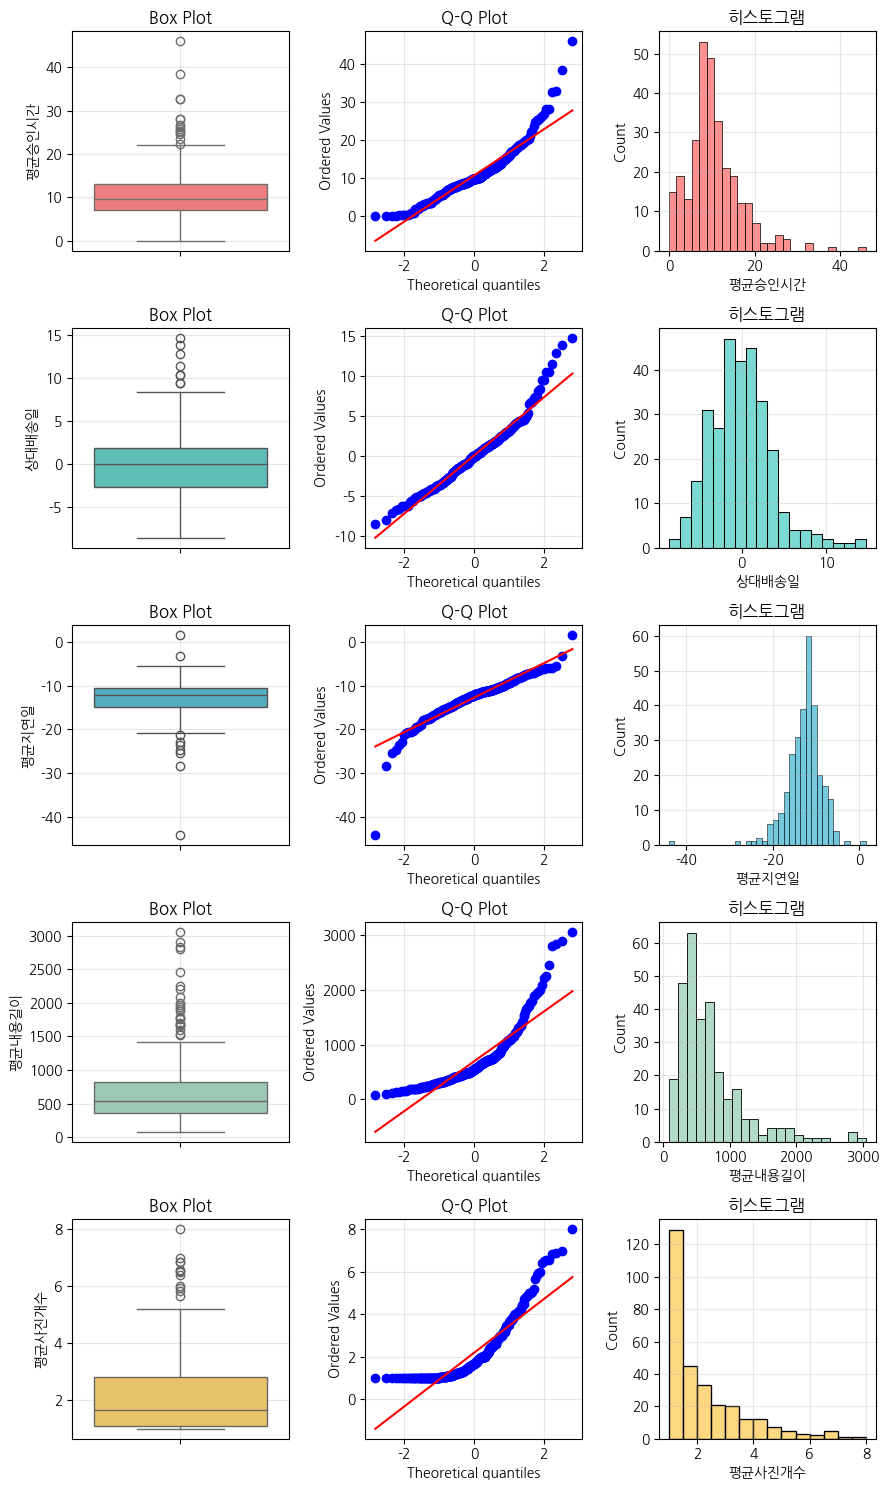

In [15]:
plot_features(category_seller[categories[0]], features, colors)

## 다중공선성 확인

In [16]:
def ols_check(category_seller_data: pd.DataFrame, features, target):
    # 모든 변수 동시 투입
    X = category_seller_data[features]
    y = category_seller_data[target]

    # 표준화 (계수 비교 위해)
    from sklearn.preprocessing import StandardScaler
    X_scaled = StandardScaler().fit_transform(X)
    X_scaled = sm.add_constant(X_scaled)

    # 회귀 분석
    model = sm.OLS(y, X_scaled).fit()
    print(model.summary())

In [17]:
ols_check(category_seller[categories[0]], features, target)

                            OLS Regression Results                            
Dep. Variable:                 평균리뷰점수   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     6.282
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           1.49e-05
Time:                        16:37:52   Log-Likelihood:                -228.20
No. Observations:                 296   AIC:                             468.4
Df Residuals:                     290   BIC:                             490.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9510      0.031    128.625      0.0

In [18]:
def check_vif(category_seller_data: pd.DataFrame, features):
    X = category_seller_data[features].copy()
    corr = X.corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.show()

    # 상수항 추가
    X = sm.add_constant(X)

    # VIF 계산
    vif_df = pd.DataFrame()
    vif_df["variable"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    display(vif_df)

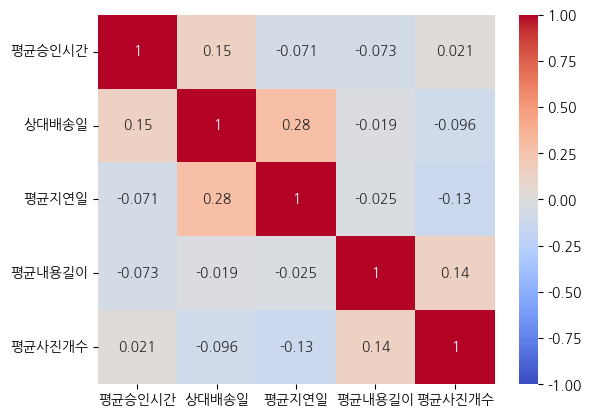

,variable,VIF
0,const,16.078804
1,평균승인시간,1.044192
2,상대배송일,1.127947
3,평균지연일,1.115769
4,평균내용길이,1.027427
5,평균사진개수,1.042865


In [19]:
check_vif(category_seller[categories[0]], features)

## 군집화 K 결정

In [20]:
data = category_seller[categories[4]]

In [21]:
def scale_data(data: pd.DataFrame, features):
    # ========================================
    # 1. 데이터 준비
    # ========================================

    # 군집화에 사용할 변수 선택

    X = data[features].copy()

    print(f"분석 대상 판매자 수: {len(X)}")
    print(f"사용 변수: {features}")
    
    # ========================================
    # 2. 데이터 표준화
    # ========================================

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # DataFrame으로 변환 (나중에 편리함)
    X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=X.index)
    return X, X_scaled, scaler

In [22]:
X, X_scaled, scaler = scale_data(data, features)

분석 대상 판매자 수: 130
사용 변수: ['평균승인시간', '상대배송일', '평균지연일', '평균내용길이', '평균사진개수']


In [23]:
def define_K(X_scaled):
    # ========================================
    # 3. 최적 k 값 탐색
    # ========================================

    k_range = range(2, 9)  # k=2~8 테스트
    inertia_list = []
    silhouette_list = []
    kmeans_models = {}

    for k in k_range:
        # K-means 수행
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        
        # 성능 지표 계산
        inertia = kmeans.inertia_  # 군집 내 분산 (낮을수록 좋음)
        silhouette = silhouette_score(X_scaled, labels)  # -1~1 (높을수록 좋음)
        
        inertia_list.append(inertia)
        silhouette_list.append(silhouette)
        kmeans_models[k] = kmeans
        
        print(f"k={k} | Inertia: {inertia:.2f} | Silhouette: {silhouette:.3f}")    

    # ========================================
    # 4. Elbow & Silhouette 차트
    # ========================================

    from plotly.subplots import make_subplots

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Elbow Method", "Silhouette Score"),
        specs=[[{"secondary_y": False}, {"secondary_y": False}]]
    )

    # Elbow Plot
    fig.add_trace(
        go.Scatter(
            x=list(k_range), y=inertia_list,
            mode='lines+markers',
            name='Inertia',
            marker=dict(size=8)
        ),
        row=1, col=1
    )

    # Silhouette Plot
    fig.add_trace(
        go.Scatter(
            x=list(k_range), y=silhouette_list,
            mode='lines+markers',
            name='Silhouette',
            marker=dict(size=8, color='coral')
        ),
        row=1, col=2
    )

    fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=1)
    fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=2)
    fig.update_yaxes(title_text="Inertia", row=1, col=1)
    fig.update_yaxes(title_text="Silhouette Score", row=1, col=2)

    fig.update_layout(
        title="Optimal k Selection",
        template="plotly_white",
        height=400
    )

    fig.show()
    
    return kmeans_models

In [24]:
kmeans_models = define_K(X_scaled)

k=2 | Inertia: 532.65 | Silhouette: 0.335
k=3 | Inertia: 452.39 | Silhouette: 0.186
k=4 | Inertia: 388.92 | Silhouette: 0.206
k=5 | Inertia: 341.99 | Silhouette: 0.223
k=6 | Inertia: 310.83 | Silhouette: 0.193
k=7 | Inertia: 286.71 | Silhouette: 0.190
k=8 | Inertia: 257.38 | Silhouette: 0.204


In [25]:
# 하나씩 category 돌려보며 판단 중
optimal_ks = [5, 5, 3, 3, 5]
optimal_ks = {
    category: k
    for category, k in zip(top5_categories, optimal_ks)
}

In [36]:
def clustering(data: pd.DataFrame, features, target, optimal_k, X, X_scaled, kmeans_models):
    # ========================================
    # 5. 군집화
    # ========================================
    clustered_data = data.copy()
    kmeans_final = kmeans_models[optimal_k]
    clustered_data.loc[:, 'cluster'] = kmeans_final.labels_

    print(f"\n✅ 최종 군집 수: {optimal_k}")
    print(f"군집별 판매자 수:\n{clustered_data['cluster'].value_counts().sort_index()}")

    # ========================================
    # 6. 군집 프로파일링
    # ========================================

    # 군집별 평균값 (원본 스케일)
    cluster_profile = clustered_data.groupby('cluster')[features].mean()

    # 추가: 평점도 확인
    cluster_profile[target] = clustered_data.groupby('cluster')[target].mean()
    cluster_profile['주문건수'] = clustered_data.groupby('cluster').size()

    print("\n📊 군집별 평균 프로파일:")
    print(cluster_profile.round(2))

    # ========================================
    # 7. 2차원 시각화 (PCA)
    # ========================================

    # 5차원 → 2차원 축소
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # DataFrame으로 변환
    pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X.index)
    pca_df['cluster'] = clustered_data['cluster']
    pca_df['review_score'] = clustered_data[target]

    # Plotly 산점도
    fig = go.Figure()

    for cluster_id in range(optimal_k):
        cluster_data = pca_df[pca_df['cluster'] == cluster_id]
        
        fig.add_trace(
            go.Scatter(
                x=cluster_data['PC1'],
                y=cluster_data['PC2'],
                mode='markers',
                name=f'Cluster {cluster_id}',
                marker=dict(
                    size=8,
                    opacity=0.7,
                    line=dict(width=0.5, color='white')
                ),
                text=cluster_data['review_score'].round(2),
                hovertemplate='PC1: %{x:.2f}<br>PC2: %{y:.2f}<br>평점: %{text}<extra></extra>'
            )
        )

    # 군집 중심 표시
    centers_pca = pca.transform(kmeans_final.cluster_centers_)
    fig.add_trace(
        go.Scatter(
            x=centers_pca[:, 0],
            y=centers_pca[:, 1],
            mode='markers',
            name='Centroids',
            marker=dict(
                symbol='x',
                size=20,
                color='black',
                line=dict(width=2)
            )
        )
    )

    fig.update_layout(
        title=f"판매자 군집 (k={optimal_k}) - PCA 2D Projection<br><sub>설명력: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}</sub>",
        xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
        yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
        template="plotly_white",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

    # ========================================
    # 8. 레이더 차트 (군집 비교)
    # ========================================

    # 표준화된 값으로 비교 (0-1 스케일)

    scaler_viz = MinMaxScaler()
    cluster_profile_scaled = pd.DataFrame(
        scaler_viz.fit_transform(cluster_profile[features]),
        columns=features,
        index=cluster_profile.index
    )

    fig = go.Figure()


    display(cluster_profile_scaled)

    for cluster_id in cluster_profile_scaled.index:
        values = cluster_profile_scaled.loc[cluster_id].tolist()
        values.append(values[0])  # 원형 완성
        
        fig.add_trace(
            go.Scatterpolar(
                r=values,
                theta=features + [features[0]],
                fill='toself',
                name=f'Cluster {cluster_id}'
            )
        )

    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 1]
            )
        ),
        title=f"군집별 특성 비교 (k={optimal_k})",
        template="plotly_white"
    )

    fig.show()
    return clustered_data

In [27]:
optimal_k = 5
clustered_data = clustering(data, features, target, optimal_k, X_scaled, kmeans_models)


✅ 최종 군집 수: 5
군집별 판매자 수:
cluster
0    30
1    34
2     9
3    52
4     5
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  상대배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0         15.64  -1.74 -12.39   400.24    3.54    4.35    30
1          7.99   3.22  -9.90   587.95    2.13    3.90    34
2          8.11   0.38 -14.22   790.95    7.17    4.10     9
3          6.90  -1.32 -15.92   540.87    2.09    4.29    52
4         18.34   1.57 -12.55  2117.45    4.04    4.51     5


,평균승인시간,상대배송일,평균지연일,평균내용길이,평균사진개수
cluster,,,,,
0,0.764410,0.000000,0.586468,0.000000,0.285485
1,0.095228,1.000000,1.000000,0.109316,0.009321
2,0.106318,0.426515,0.282298,0.227530,1.000000
3,0.000000,0.085152,0.000000,0.081898,0.000000
4,1.000000,0.668577,0.559197,1.000000,0.385097


In [28]:
def anova_anlysis(data: pd.DataFrame, features, target, colors):
    # ========================================
    # 9. 통계 검증 (군집 간 평점 차이)
    # ========================================

    anova_data = data.copy()
    anova_data['cluster'] = anova_data['cluster'].astype('category')

    labels = anova_data['cluster'].cat.categories.tolist()
    print(labels)
    clusters = [anova_data[anova_data['cluster'] == i][target] for i in labels]

    # 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
    cluster_colors = colors[:optimal_k]

    var1 = '판매자'
    var2 = '리뷰점수'
    label = '거래량'


    fig = plt.figure(figsize=(14, 10))
    ax1 = plt.subplot(2, 2, 1)

    # 박스플롯

    plot_box(ax1, clusters, tick_labels= labels, ylabel=label, color=cluster_colors, xrotation=30)

    # 평균 및 오차막대
    ax2 = plt.subplot(2, 2, 2)
    plot_mean_sem(clusters, ax2, var1, var2, labels, cluster_colors, 30)

    # 산점도 with jitter
    ax3 = plt.subplot(2, 2, 3)
    plot_scatter_jitter(clusters, ax3, var1, var2, labels, cluster_colors, xrotation=30)

    # 밀도 플롯
    ax4 = plt.subplot(2, 2, 4)
    for label, data, color in zip(labels, clusters, cluster_colors):
        density = stats.gaussian_kde(data)
        x_range = np.linspace(data.min() - 20, data.max() + 20, 100)
        ax4.plot(x_range, density(x_range), label=label, color=color, linewidth=2)
    ax4.set_title(f'{var1}별 {var2} 밀도 분포')
    ax4.set_xlabel(var2)
    ax4.set_ylabel('밀도')
    ax4.set_xlim(0, 6)
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


    # =============================================================================
    # ANOVA 분석 수행
    # =============================================================================
    print("\n[일원배치 ANOVA]")
    print("-"*50)

    print(f"H₀: {var1}마다 평균 {var2} 모두 같다")
    print(f"H₁: 적어도 한 {var1}의 평균{var2} 다르다")
    print("유의수준: α = 0.05")

    # -----------------------------------------------------------------------------
    # 1. ANOVA 가정 검정
    # -----------------------------------------------------------------------------
    is_normal = check_normality(clusters, labels)
    is_equal_var = check_homogeneity(clusters, labels)

    # -----------------------------------------------------------------------------
    # 2. ANOVA 수행 (정규성 위반 시 Kruskal-Wallis 고려)
    # -----------------------------------------------------------------------------
    print("\n[ANOVA 검정 결과]")
    print("-"*50)

    if not is_normal:
        print("⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.")
        print("\n[Kruskal-Wallis 검정 (비모수 검정)]")
        print("\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음")
        print("-"*50)
        h_stat, p_value = stats.kruskal(*clusters)
        
        # 자유도 및 효과 크기 계산
        k = len(clusters)
        N = sum(len(group) for group in clusters)
        df = k - 1
        
        # 비모수 효과 크기 계산
        epsilon_sq, effect_interpretation = calculate_epsilon_squared(h_stat, k, N)
        
        print(f"H-통계량: {h_stat:.4f}")
        print(f"자유도: {df}")
        print(f"p-value: {p_value:.6f}")
        print(f"효과 크기 (ε²): {epsilon_sq:.4f} ({effect_interpretation})")
        print(f"   → {var1} 차이가 전체 {var2} 변동의 {epsilon_sq*100:.1f}% 설명")
        
        # 결론
        print("\n[검정 결론]")
        if p_value < 0.05:
            print(f"✅ p-value({p_value:.6f}) < 0.05 → 귀무가설 기각")
            print(f"   {var1}별 {var2}에 유의한 차이가 있음")
        else:
            print(f"❌ p-value({p_value:.6f}) ≥ 0.05 → 귀무가설 채택")
            print(f"   {var1}별 {var2}에 유의한 차이가 없음")

    # ========================================
    # 10. 결과 저장
    # ========================================

    # 군집 라벨이 추가된 데이터 저장
    clustered_seller = anova_data[['seller_id', 'cluster'] + features + [target]]
    return clustered_seller, round(epsilon_sq*100, 1)

[0, 1, 2, 3, 4]


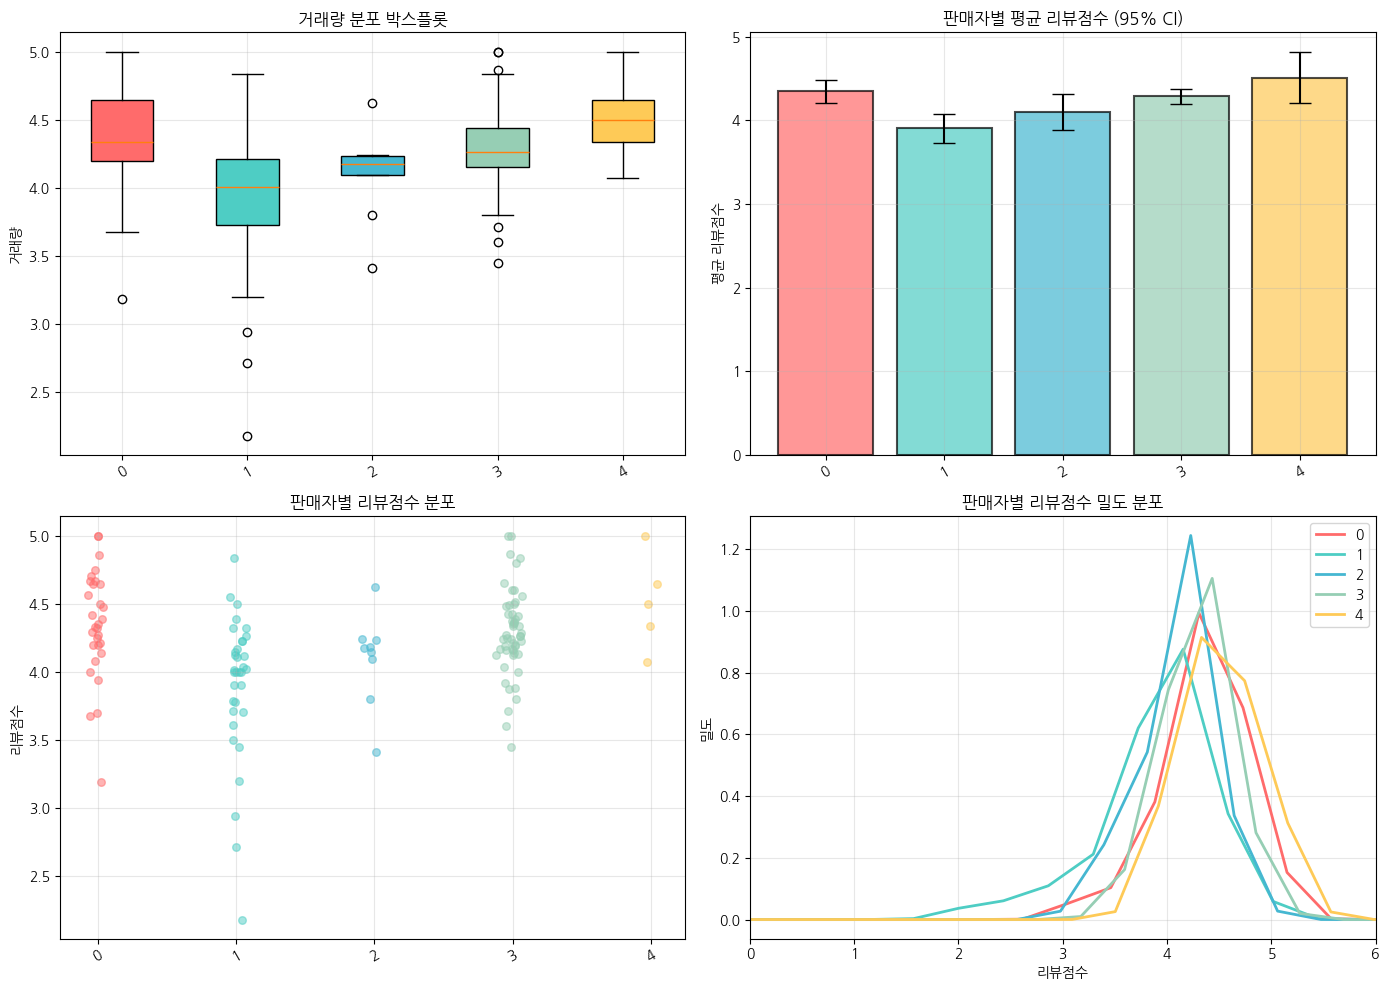


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.9549   0.2286  정규분포 ✓
1   1  0.8912   0.0027  정규분포 X
2   2  0.8838   0.1723  정규분포 ✓
3   3  0.9727   0.2750  정규분포 ✓
4   4  0.9942   0.9921  정규분포 ✓

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 1.0814
p-value: 0.3686
✅ 등분산성 가정을 만족합니다.

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 24.8835
자유도: 4
p-value: 0.000053
효과 크기 (ε²): 0.1671 (큰 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 16.7% 설명

[검정 결론]
✅ p-value(0.000053) < 0.05 → 귀무가설 기각
   판매자별 리뷰점수에 유의한 차이가 있음


In [29]:

# 군집 라벨이 추가된 데이터 저장
clustered_seller, effect = anova_anlysis(clustered_data, features, target, colors)
# filtered_seller[['seller_id', 'cluster'] + features + ['avg_review_score']].to_csv(
#     'seller_clusters.csv', index=False
# )

# print("\n✅ 분석 완료! seller_clusters.csv 저장됨")

In [37]:
def clustering_all_process(data: pd.DataFrame, features, target, colors, optimal_k):
    X, X_scaled, scaler = scale_data(data, features)
    kmeans_models = define_K(X_scaled)
    clustered_data = clustering(data, features, target, optimal_k, X, X_scaled, kmeans_models)
    clustered_seller, effect = anova_anlysis(clustered_data, features, target, colors)
    return scaler, kmeans_models, clustered_seller, effect

분석 대상 판매자 수: 296
사용 변수: ['평균승인시간', '상대배송일', '평균지연일', '평균내용길이', '평균사진개수']
k=2 | Inertia: 1215.26 | Silhouette: 0.274
k=3 | Inertia: 1041.70 | Silhouette: 0.180
k=4 | Inertia: 898.16 | Silhouette: 0.198
k=5 | Inertia: 785.52 | Silhouette: 0.213
k=6 | Inertia: 717.99 | Silhouette: 0.202
k=7 | Inertia: 663.75 | Silhouette: 0.194
k=8 | Inertia: 624.41 | Silhouette: 0.191



✅ 최종 군집 수: 5
군집별 판매자 수:
cluster
0     33
1     24
2     41
3    111
4     87
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  상대배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0         22.35   0.63 -15.82   595.09    1.98    3.89    33
1          7.27  -0.46 -12.83  1969.99    2.28    4.05    24
2          9.63  -1.32 -13.16   761.26    4.91    4.17    41
3          8.45  -2.28 -13.97   523.93    1.64    4.00   111
4         10.07   3.42  -9.87   563.72    1.63    3.78    87


,평균승인시간,상대배송일,평균지연일,평균내용길이,평균사진개수
cluster,,,,,
0,1.000000,0.510872,0.000000,0.049209,0.106215
1,0.000000,0.319911,0.502290,1.000000,0.199137
2,0.156539,0.169048,0.446733,0.164120,1.000000
3,0.078654,0.000000,0.311060,0.000000,0.003664
4,0.185995,1.000000,1.000000,0.027518,0.000000


[0, 1, 2, 3, 4]


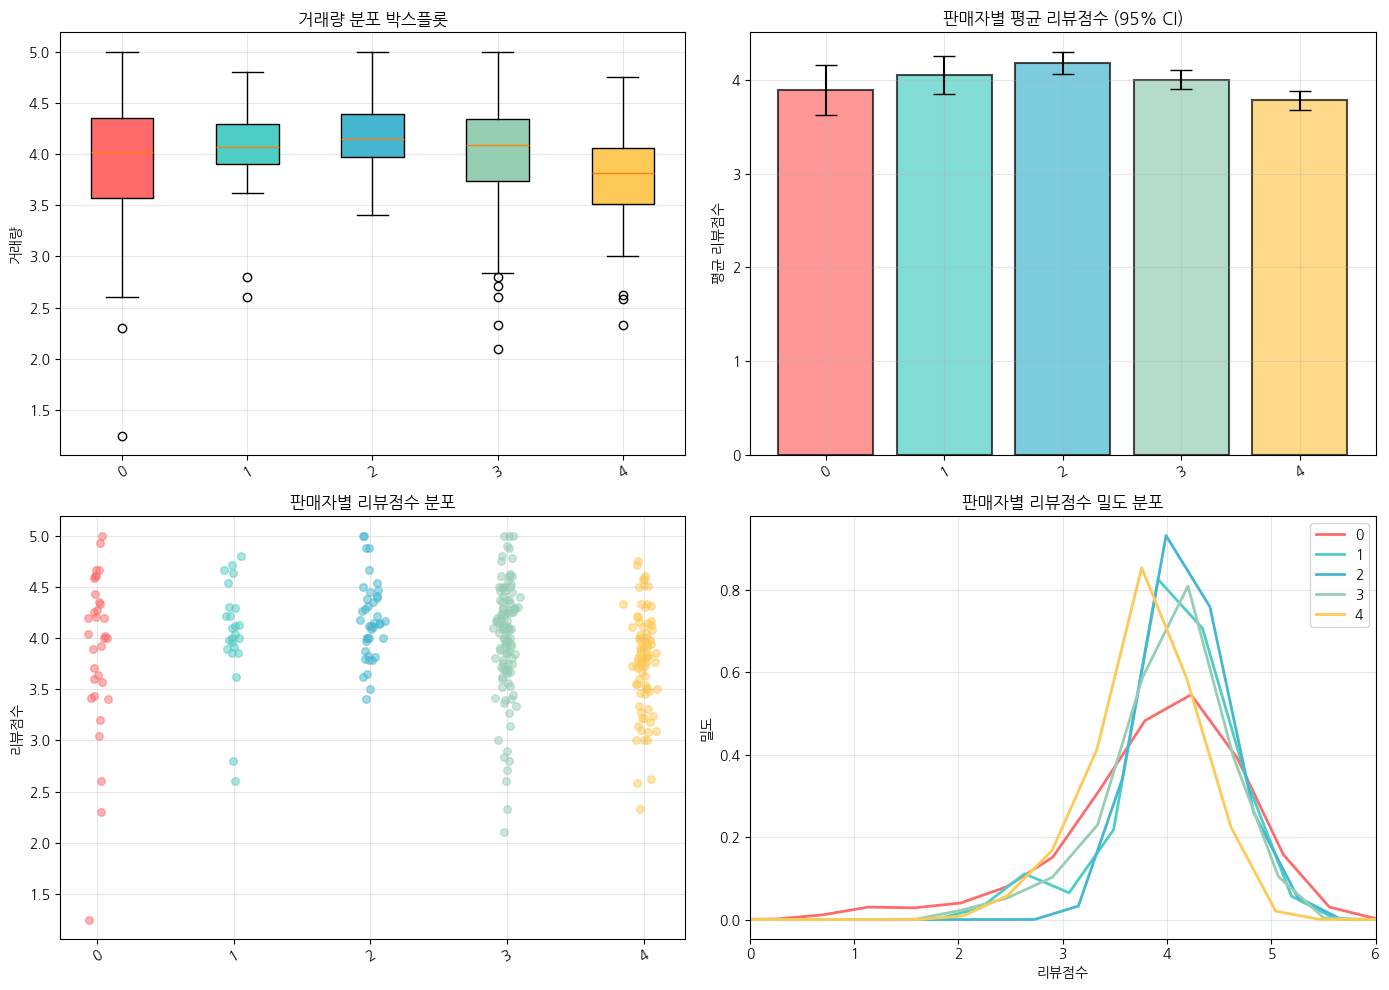


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.8997   0.0052  정규분포 X
1   1  0.8648   0.0042  정규분포 X
2   2  0.9755   0.5121  정규분포 ✓
3   3  0.9486   0.0003  정규분포 X
4   4  0.9766   0.1169  정규분포 ✓

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 2.6267
p-value: 0.0348
⚠️ 등분산성 가정을 만족하지 않습니다.
   → Welch's ANOVA 또는 Games-Howell 사후검정 권장

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 21.9616
자유도: 4
p-value: 0.000204
효과 크기 (ε²): 0.0617 (중간 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 6.2% 설명

[검정 결론]
✅ p-value(0.000204) < 0.05 → 귀무가설


✅ 최종 군집 수: 5
군집별 판매자 수:
cluster
0    102
1    204
2     51
3     71
4     53
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  상대배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0          9.72   4.49  -8.90   654.39    2.16    3.91   102
1          7.00  -1.72 -13.25   642.95    1.83    4.26   204
2         10.22   1.42 -12.43  1881.48    2.82    4.15    51
3          8.53  -1.11 -13.81   830.84    4.93    4.29    71
4         21.69  -1.88 -12.19   779.31    2.45    4.25    53


,평균승인시간,상대배송일,평균지연일,평균내용길이,평균사진개수
cluster,,,,,
0,0.185340,1.000000,1.000000,0.009237,0.107308
1,0.000000,0.025060,0.115302,0.000000,0.000000
2,0.219235,0.518175,0.282402,1.000000,0.319386
3,0.104333,0.120685,0.000000,0.151703,1.000000
4,1.000000,0.000000,0.330838,0.110096,0.201462


[0, 1, 2, 3, 4]


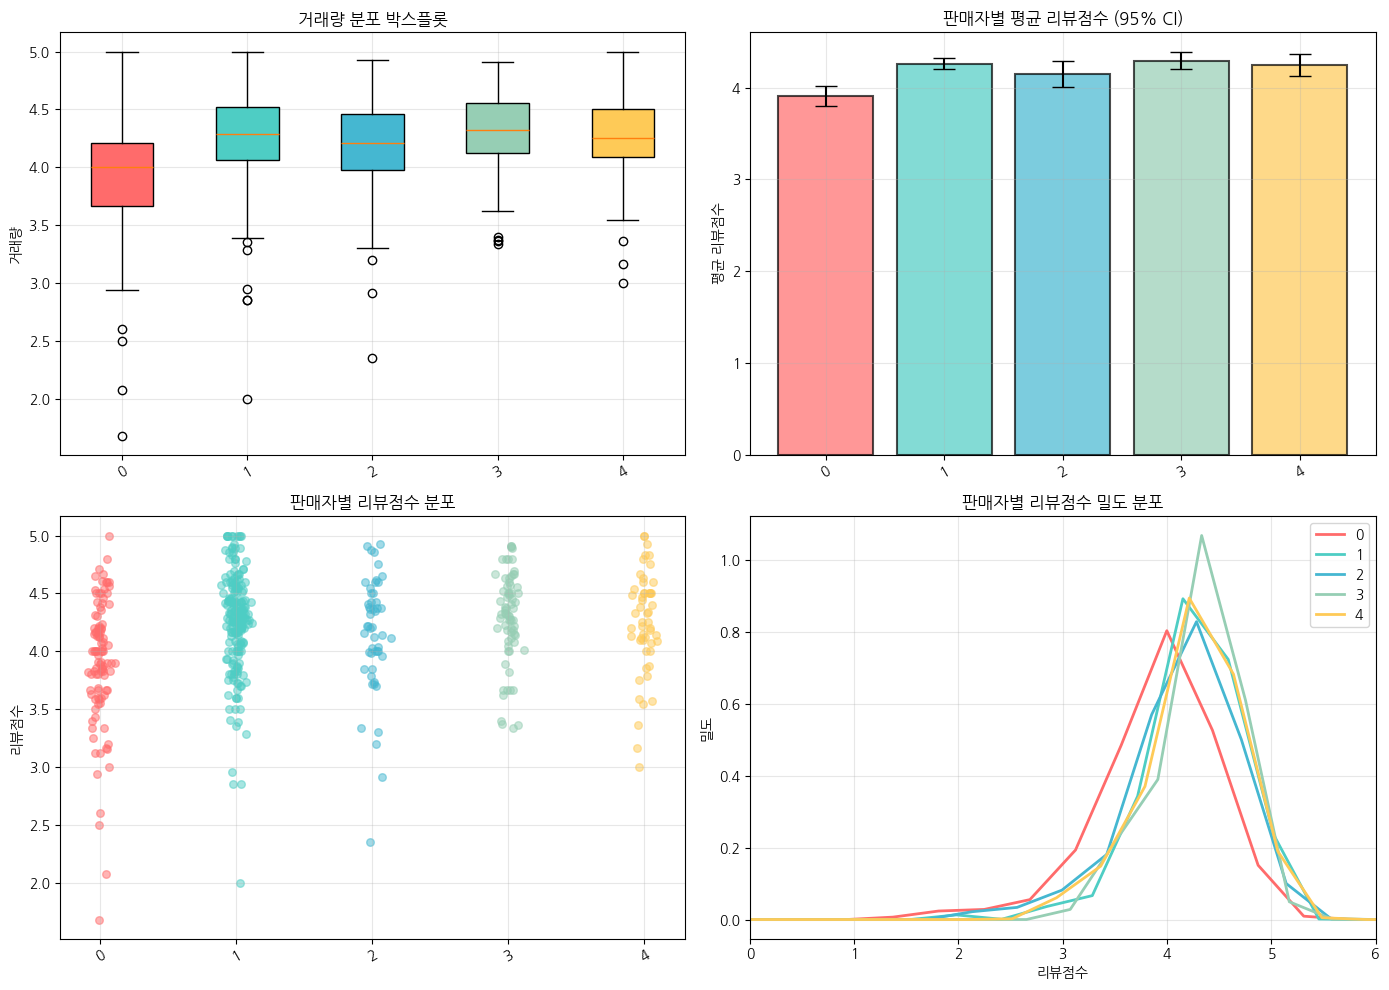


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.9310   0.0000  정규분포 X
1   1  0.9347   0.0000  정규분포 X
2   2  0.9247   0.0031  정규분포 X
3   3  0.9470   0.0047  정규분포 X
4   4  0.9595   0.0698  정규분포 ✓

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 1.7654
p-value: 0.1346
✅ 등분산성 가정을 만족합니다.

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 40.4443
자유도: 4
p-value: 0.000000
효과 크기 (ε²): 0.0766 (중간 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 7.7% 설명

[검정 결론]
✅ p-value(0.000000) < 0.05 → 귀무가설 기각
   판매자별 리뷰점수에 유의한 차이가 있음
분석 대상 판매자 수: 253
사용


✅ 최종 군집 수: 3
군집별 판매자 수:
cluster
0    190
1     22
2     41
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  상대배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0         10.86  -1.09 -12.63   748.43    1.96    4.09   190
1         10.64  10.30  -3.47   721.54    1.68    3.59    22
2         15.39  -0.46 -11.73  1732.49    4.22    4.18    41


,평균승인시간,상대배송일,평균지연일,평균내용길이,평균사진개수
cluster,,,,,
0,0.044793,0.000000,0.000000,0.026602,0.111258
1,0.000000,1.000000,1.000000,0.000000,0.000000
2,1.000000,0.056108,0.097573,1.000000,1.000000


[0, 1, 2]


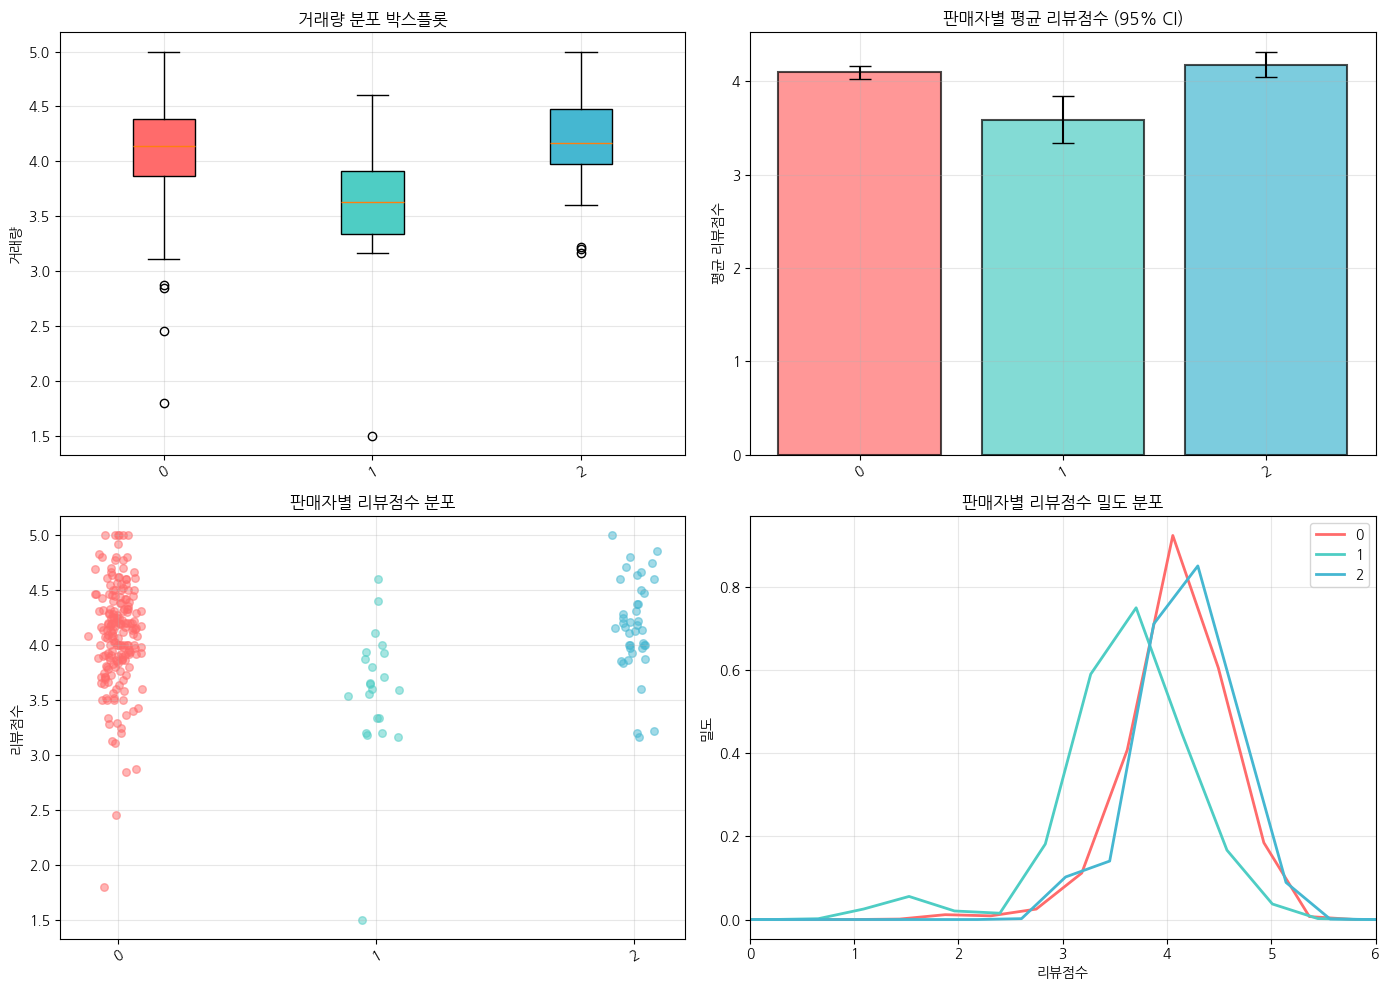


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.9542   0.0000  정규분포 X
1   1  0.8409   0.0024  정규분포 X
2   2  0.9563   0.1170  정규분포 ✓

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 0.3250
p-value: 0.7228
✅ 등분산성 가정을 만족합니다.

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 21.3856
자유도: 2
p-value: 0.000023
효과 크기 (ε²): 0.0775 (중간 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 7.8% 설명

[검정 결론]
✅ p-value(0.000023) < 0.05 → 귀무가설 기각
   판매자별 리뷰점수에 유의한 차이가 있음
분석 대상 판매자 수: 262
사용 변수: ['평균승인시간', '상대배송일', '평균지연일', '평균내용길이', '평균사진개수']
k=2 | In


✅ 최종 군집 수: 3
군집별 판매자 수:
cluster
0     53
1    173
2     36
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  상대배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0          7.64   5.32  -7.93  1027.16    1.59    4.01    53
1          9.30  -1.57 -12.91   898.23    1.44    4.34   173
2         13.72  -0.31 -12.57  1862.92    3.97    4.22    36


,평균승인시간,상대배송일,평균지연일,평균내용길이,평균사진개수
cluster,,,,,
0,0.000000,1.000000,1.000000,0.133647,0.058678
1,0.272242,0.000000,0.000000,0.000000,0.000000
2,1.000000,0.181761,0.068577,1.000000,1.000000


[0, 1, 2]


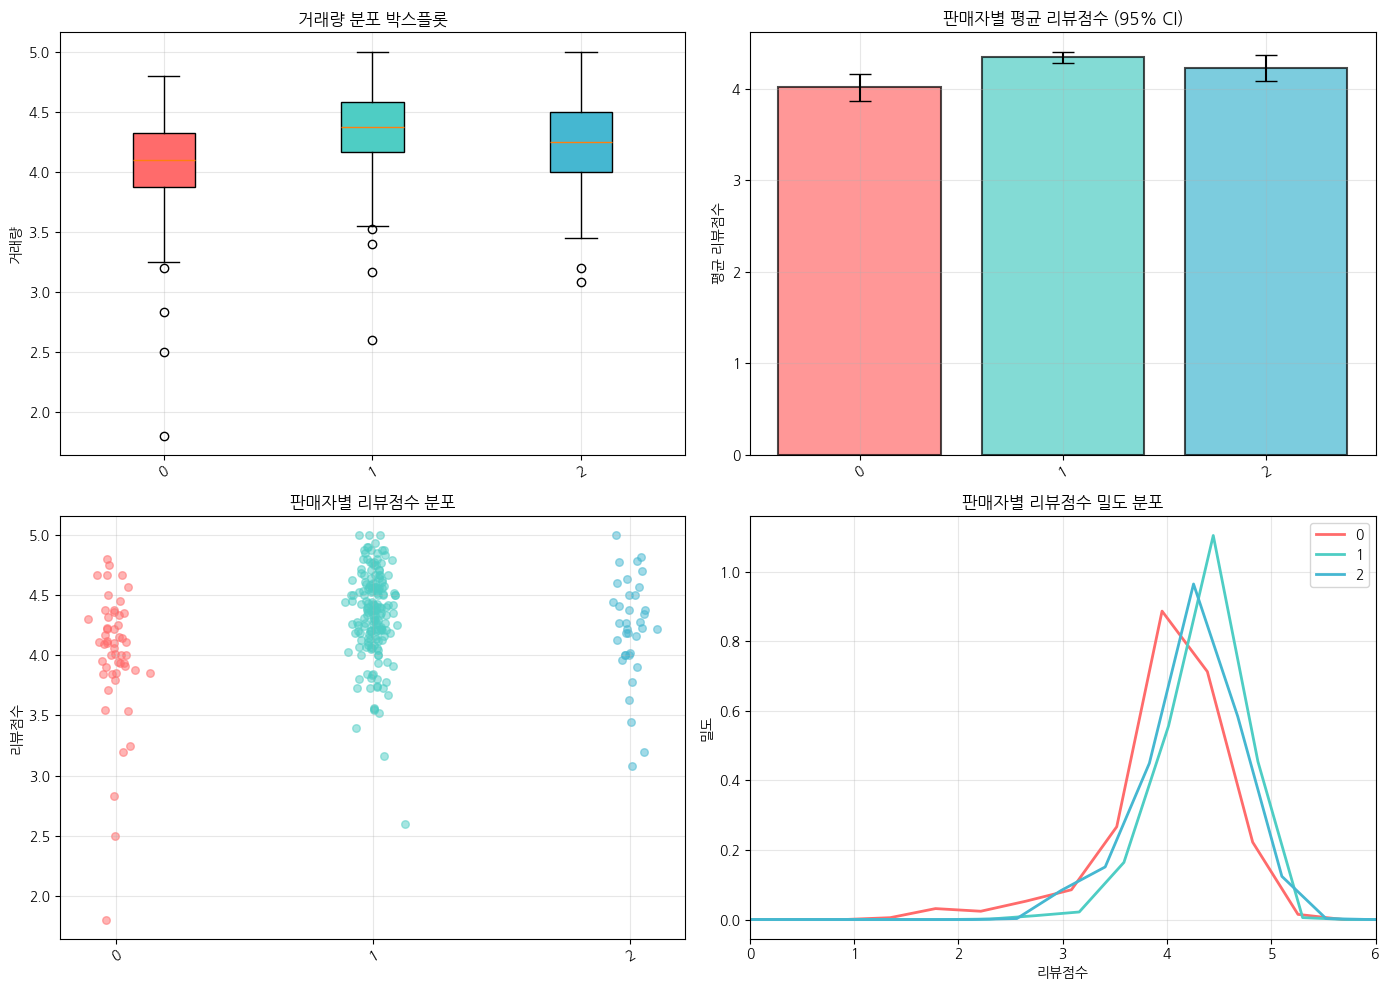


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.8390   0.0000  정규분포 X
1   1  0.9515   0.0000  정규분포 X
2   2  0.9539   0.1384  정규분포 ✓

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 1.0026
p-value: 0.3684
✅ 등분산성 가정을 만족합니다.

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 22.8318
자유도: 2
p-value: 0.000011
효과 크기 (ε²): 0.0804 (중간 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 8.0% 설명

[검정 결론]
✅ p-value(0.000011) < 0.05 → 귀무가설 기각
   판매자별 리뷰점수에 유의한 차이가 있음
분석 대상 판매자 수: 130
사용 변수: ['평균승인시간', '상대배송일', '평균지연일', '평균내용길이', '평균사진개수']
k=2 | In


✅ 최종 군집 수: 5
군집별 판매자 수:
cluster
0    30
1    34
2     9
3    52
4     5
Name: count, dtype: int64

📊 군집별 평균 프로파일:
         평균승인시간  상대배송일  평균지연일   평균내용길이  평균사진개수  평균리뷰점수  주문건수
cluster                                                     
0         15.64  -1.74 -12.39   400.24    3.54    4.35    30
1          7.99   3.22  -9.90   587.95    2.13    3.90    34
2          8.11   0.38 -14.22   790.95    7.17    4.10     9
3          6.90  -1.32 -15.92   540.87    2.09    4.29    52
4         18.34   1.57 -12.55  2117.45    4.04    4.51     5


,평균승인시간,상대배송일,평균지연일,평균내용길이,평균사진개수
cluster,,,,,
0,0.764410,0.000000,0.586468,0.000000,0.285485
1,0.095228,1.000000,1.000000,0.109316,0.009321
2,0.106318,0.426515,0.282298,0.227530,1.000000
3,0.000000,0.085152,0.000000,0.081898,0.000000
4,1.000000,0.668577,0.559197,1.000000,0.385097


[0, 1, 2, 3, 4]


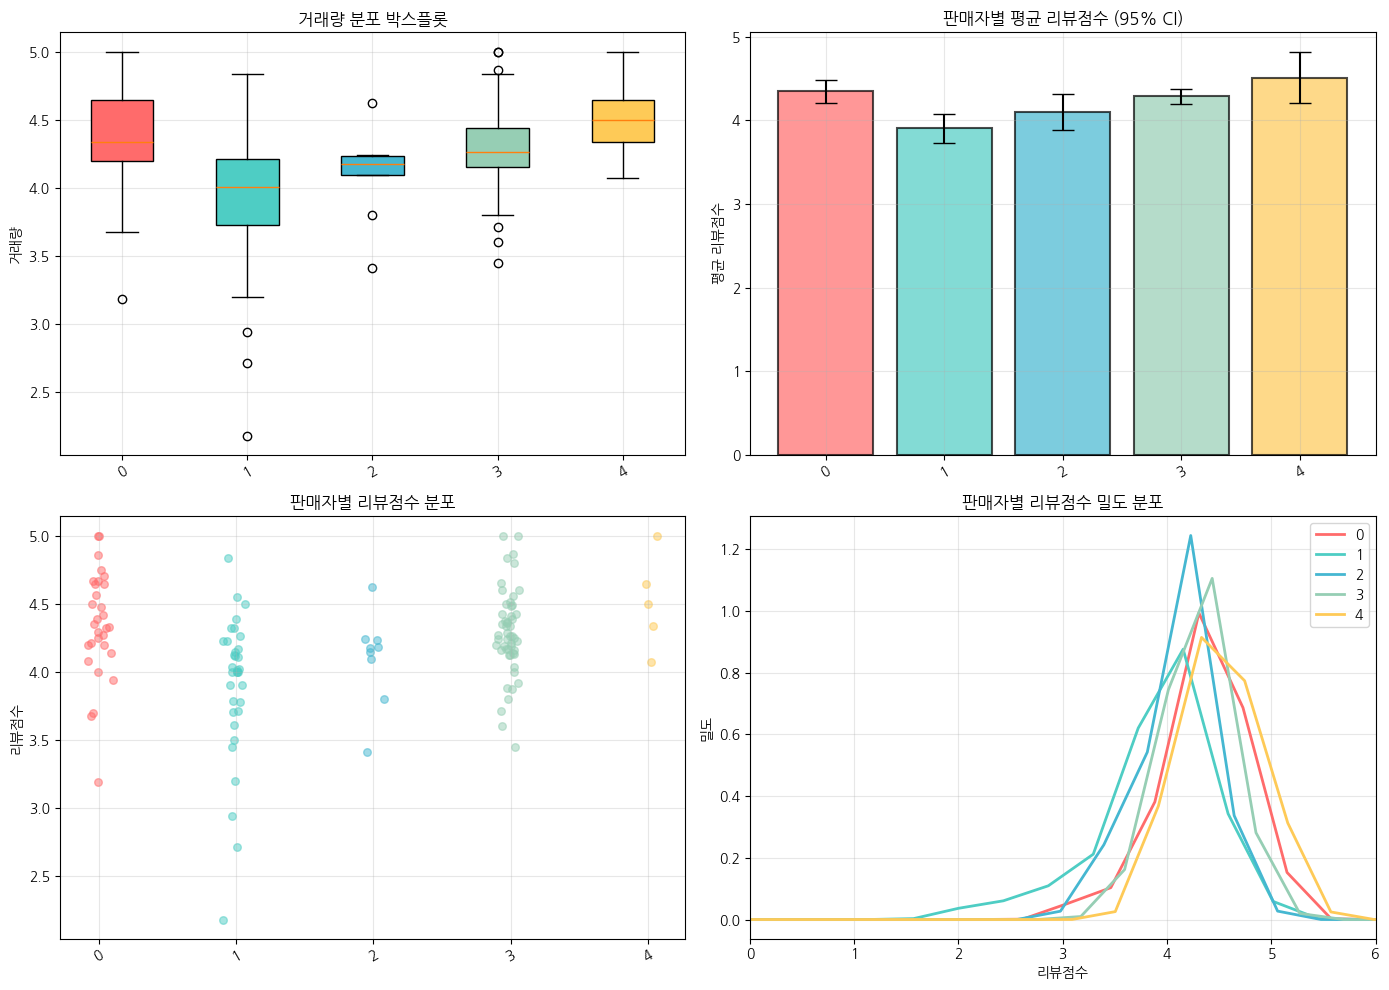


[일원배치 ANOVA]
--------------------------------------------------
H₀: 판매자마다 평균 리뷰점수 모두 같다
H₁: 적어도 한 판매자의 평균리뷰점수 다르다
유의수준: α = 0.05

[정규성 검정 - Shapiro-Wilk Test]
--------------------------------------------------
   그룹   W-통계량  p-value      판정
0   0  0.9549   0.2286  정규분포 ✓
1   1  0.8912   0.0027  정규분포 X
2   2  0.8838   0.1723  정규분포 ✓
3   3  0.9727   0.2750  정규분포 ✓
4   4  0.9942   0.9921  정규분포 ✓

⚠️ 일부 그룹이 정규성 가정을 만족하지 않습니다.
   → 비모수 검정(Kruskal-Wallis) 고려

[등분산성 검정 - Levene's Test]
--------------------------------------------------
Levene 통계량: 1.0814
p-value: 0.3686
✅ 등분산성 가정을 만족합니다.

[ANOVA 검정 결과]
--------------------------------------------------
⚠️ 정규성 가정이 위반되었으므로 비모수 검정을 수행합니다.

[Kruskal-Wallis 검정 (비모수 검정)]
\- Kruskal-Wallis 검정은 또한 등분산성 가정이 필요 없음
--------------------------------------------------
H-통계량: 24.8835
자유도: 4
p-value: 0.000053
효과 크기 (ε²): 0.1671 (큰 효과)
   → 판매자 차이가 전체 리뷰점수 변동의 16.7% 설명

[검정 결론]
✅ p-value(0.000053) < 0.05 → 귀무가설 기각
   판매자별 리뷰점수에 유의한 차이가 있음


In [38]:
for category in top5_categories:
    data = category_seller[category]
    optimal_k = optimal_ks[category]
    clustering_all_process(data, features, target, colors, optimal_k)

In [ ]:
# 군집 중심값 추출 (표준화된 스케일)
kmeans_final = kmeans_models[optimal_k]
centers_scaled = kmeans_final.cluster_centers_

# DataFrame으로 변환
centers_df = pd.DataFrame(
    centers_scaled,
    columns=features,
    index=[f'Cluster {i}' for i in range(optimal_k)]
)

print("📍 군집 중심 (표준화된 값):")
print(centers_df.round(3))



def explain_cluster_assignment(seller_id, seller_data, kmeans_model, scaler, feature_columns):
    """
    특정 판매자가 왜 해당 군집에 배정되었는지 설명
    """
    # 판매자 데이터 추출
    seller = seller_data[seller_data['seller_id'] == seller_id]
    seller_features = seller[feature_columns].values[0]
    seller_cluster = seller['cluster'].values[0]
    
    # 표준화
    seller_scaled = scaler.transform([seller_features])[0]
    
    # 각 군집 중심까지 거리 계산
    centers = kmeans_model.cluster_centers_
    distances = {}
    
    for i, center in enumerate(centers):
        dist = np.sqrt(np.sum((seller_scaled - center) ** 2))
        distances[i] = dist
    
    # 결과 출력
    print(f"🔍 판매자 {seller_id} 분석")
    print(f"   배정된 군집: Cluster {seller_cluster}")
    print(f"\n📏 각 군집 중심까지의 거리:")
    
    for cluster_id, dist in sorted(distances.items(), key=lambda x: x[1]):
        marker = "✅ 배정됨" if cluster_id == seller_cluster else ""
        print(f"   Cluster {cluster_id}: {dist:.3f} {marker}")
    
    # 차원별 기여도 분석
    assigned_center = centers[seller_cluster]
    dim_contributions = (seller_scaled - assigned_center) ** 2
    
    print(f"\n📊 배정 이유 (차원별 기여도):")
    contributions_df = pd.DataFrame({
        '변수': feature_columns,
        '판매자값(표준화)': seller_scaled,
        '중심값(표준화)': assigned_center,
        '거리제곱': dim_contributions,
        '기여도(%)': dim_contributions / dim_contributions.sum() * 100
    })
    
    contributions_df = contributions_df.sort_values('기여도(%)', ascending=False)
    print(contributions_df.to_string(index=False))
    
    # 해석
    top_feature = contributions_df.iloc[0]['변수']
    top_contribution = contributions_df.iloc[0]['기여도(%)']
    
    print(f"\n💡 핵심 이유: '{top_feature}'가 이 군집과 가장 유사 (기여도 {top_contribution:.1f}%)")
    
    return contributions_df

# 사용 예시
# explain_cluster_assignment(
#     seller_id='da8622b14eb17ae2831f4ac5b9dab84a',  # 분석할 판매자 ID
#     seller_data=data,
#     kmeans_model=kmeans_final,
#     scaler=scaler,
#     feature_columns=features
# )



def analyze_cluster_importance(kmeans_model, feature_columns):
    """
    어떤 변수가 군집 구분에 가장 중요했는지 분석
    """
    centers = kmeans_model.cluster_centers_
    
    # 군집 간 중심 거리 (변수별)
    # 중심들 간 표준편차 = 군집 분리에 얼마나 기여했는지
    
    importance = {}
    for i, feature in enumerate(feature_columns):
        # 각 변수 차원에서 군집 중심들의 표준편차
        center_values = centers[:, i]
        std = np.std(center_values)
        importance[feature] = std
    
    # 정규화 (합 = 100%)
    total = sum(importance.values())
    importance_pct = {k: v/total*100 for k, v in importance.items()}
    
    # DataFrame으로 정리
    importance_df = pd.DataFrame({
        '변수': importance_pct.keys(),
        '중요도(%)': importance_pct.values()
    }).sort_values('중요도(%)', ascending=False)
    
    print("📊 군집 구분에 중요한 변수 순위:")
    print(importance_df.to_string(index=False))
    
    # 시각화
    import plotly.express as px
    fig = px.bar(
        importance_df, 
        x='변수', 
        y='중요도(%)',
        title='K-means 군집화 변수 중요도',
        text='중요도(%)'
    )
    fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    fig.show()
    
    return importance_df

# 실행
importance_df = analyze_cluster_importance(kmeans_final, features)

In [ ]:
display(clustered_seller)

In [ ]:
clustered_seller.info()

In [ ]:
review_group = lambda x: 0 if x < 4.2 else 1 if x < 4.75 else 2
clustered_seller = clustered_seller[clustered_seller['평균리뷰점수'] != 5]
clustered_seller.loc[:, '리뷰점수그룹'] = clustered_seller['평균리뷰점수'].map(review_group)
clustered_seller.head(10)

In [ ]:
clustered_seller['리뷰점수그룹'].value_counts()

## t-test

In [ ]:
cluster_review_data = clustered_seller.groupby(['cluster', '리뷰점수그룹'], observed=False).size().unstack()
cluster_review_data

In [ ]:
# 색상 목록 정의 (RGB 튜플 또는 16진수 코드 사용)
distance_colormap = 'cool'

review_colormap = 'hot'

var1 = '판매자'
var2 = '리뷰'
label = '고객수'


# 데이터 시각화
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 누적 막대그래프
plot_stacked_bar(cluster_review_data, axes[0], var1, var2, label, cmap=distance_colormap)

# 히트맵 -> 비율 or 스케일링해서 보여주면 될 것 같다.
plot_heatmap(cluster_review_data, axes[1], var1, var2, label, normalize='column')


# 비율 막대그래프
plot_prop_bar(cluster_review_data, axes[2], var1, var2, cmap=review_colormap, xrotation=30)


plt.tight_layout()
plt.show()

In [ ]:
# 기대빈도 확인 (카이제곱 적절성 판단)
is_valid = check_expected_frequencies(cluster_review_data)

In [ ]:
# 적절한 검정 선택 및 수행 

print("\n[카이제곱 독립성 검정]")
print('-'*40)

alpha = 0.05

# 가설 설정
print(f"H₀: {var1} & {var2} - 독립적이다")
print(f"H₁: {var1} & {var2} - 관련이 있다")
print(f"유의수준: α = {alpha}")


chi2_stat, p_value, dof, expected = chi2_contingency(cluster_review_data)

print(f"\n카이제곱 통계량: {chi2_stat:.4f}")
print(f"자유도: {dof}")  # df = (행수-1) × (열수-1)
print(f"p-value: {p_value:.4f}")

In [ ]:
# 효과 크기 계산

n = cluster_review_data.values.sum()
r, c = cluster_review_data.shape
v = cramers_v(chi2_stat, n, r, c)

print(f"Cramér's V: {v:.3f} ({interpret_cramers_v(v)})")

In [ ]:
# 잔차 분석 또는 Odds 분석 (필요한 경우)

expected_df = pd.DataFrame(expected, 
                           index=cluster_review_data.index,
                           columns=cluster_review_data.columns)
print("\n[기대빈도]")
display(expected_df.round(2))


# 각 셀이 독립성 가정에서 얼마나 벗어났는지 측정
# 표준화 잔차 = (관측값 - 기대값) / sqrt(기대값)
std_residuals = standardized_residuals(cluster_review_data.values, expected)
residuals_df = pd.DataFrame(std_residuals,
                            index=cluster_review_data.index,
                            columns=cluster_review_data.columns)
print("\n[표준화 잔차]")
display(residuals_df.round(2))
print("(|잔차| > 2: 유의한 차이, |잔차| > 3: 매우 강한 연관성)")

In [ ]:
# 해석

print("\n[결론]")

# p-value를 유의수준과 비교하여 가설 채택/기각 결정
if p_value < 0.05:
    print(f"✅ p-value({p_value:.4f}) < 0.05 → 귀무가설 기각")
    print(f"   {var1} & {var2} - 관련이 있다")
    print(f"   효과 크기: {interpret_cramers_v(v)}")
    
    # -------------------------------------------------------------------------
    # 6. 사후 분석 (Post-hoc Analysis)
    # -------------------------------------------------------------------------
    # 표준화 잔차를 통해 어느 조합이 특히 연관성이 강한지 분석
    print("\n[구체적 패턴 분석]")
    print("   표준화 잔차 |값| > 2인 셀 해석:")
    
    for i, grade in enumerate(cluster_review_data.index):
        for j, lang in enumerate(cluster_review_data.columns):
            # |잔차| > 2: 해당 조합이 독립성에서 유의하게 벗어남
            if abs(std_residuals[i, j]) > 2:
                if std_residuals[i, j] > 0:
                    # 양수: 관측값 > 기대값 (과대 표현)
                    print(f"   • {grade} - {lang}: 예상보다 높음 (잔차={std_residuals[i, j]:.2f})")
                else:
                    # 음수: 관측값 < 기대값 (과소 표현)
                    print(f"   • {grade} - {lang}: 예상보다 낮음 (잔차={std_residuals[i, j]:.2f})")
else:
    print(f"❌ p-value({p_value:.4f}) ≥ 0.05 → 귀무가설 채택")
    print(f"   {var1} & {var2} - 독립적이다")
    print(f"   ({var1} -> {var2}에 영향을 주지 않음)")